<a href="https://colab.research.google.com/github/Sanskarmeharkar/Generative-AI/blob/main/genrative_ai_lab_paractical_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Neural Network Implementation from Scratch
**MIT Academy of Engineering, Alandi, Pune,**
Department of CSE (AIML) — Course: Generative AI Lab Class: T.Y. Tech

**Student Information:**

*  Name: `Sanskar meharkar`

* PRN Number: `202401110029`

* Batch: `A1`

* Date of Submission: `15th August 2026 `




**Objective:**
Implement a simple feedforward neural network from scratch in Python — no in-built deep learning libraries (no TensorFlow/PyTorch/Keras) — covering the forward pass, backpropagation, and training using gradient descent.

Part A — Problem Definition

Dataset: sklearn.datasets.load_digits — 1,797 samples of handwritten digits (0–9), each an 8×8 grayscale image (64 features), flattened to a 64-dim vector. This is a smaller, self-contained stand-in for MNIST that doesn't require any external download, so the notebook runs end-to-end offline.

Task: Multi-class classification — predict the digit (0–9) from the 64 pixel-intensity features.

Note on libraries: numpy is used for all the math (matrix ops, gradients, weight updates). sklearn is used only to load the dataset, split it, and compute a confusion matrix for evaluation — it is not used to build or train the network. matplotlib is used purely for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
%matplotlib inline

Part B — Load and Preprocess the Dataset

Steps:

1. Load the digits dataset.

2. Normalize pixel values to the range [0, 1].

3. One-hot encode the labels (needed for cross-entropy loss with a softmax output layer).

4. Split into train (80%) and test (20%) sets.

In [2]:
digits = load_digits()
X = digits.data.astype(np.float64)   # shape (1797, 64)
y = digits.target                    # shape (1797,)

# Normalize pixel intensities to [0, 1]
X = X / 16.0

# One-hot encode labels
num_classes = 10
Y_onehot = np.eye(num_classes)[y]

# Train/test split
X_train, X_test, y_train, y_test, Y_train, Y_test = train_test_split(
    X, y, Y_onehot, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, Y_train.shape)
print("Test set: ", X_test.shape, Y_test.shape)

Train set: (1437, 64) (1437, 10)
Test set:  (360, 64) (360, 10)


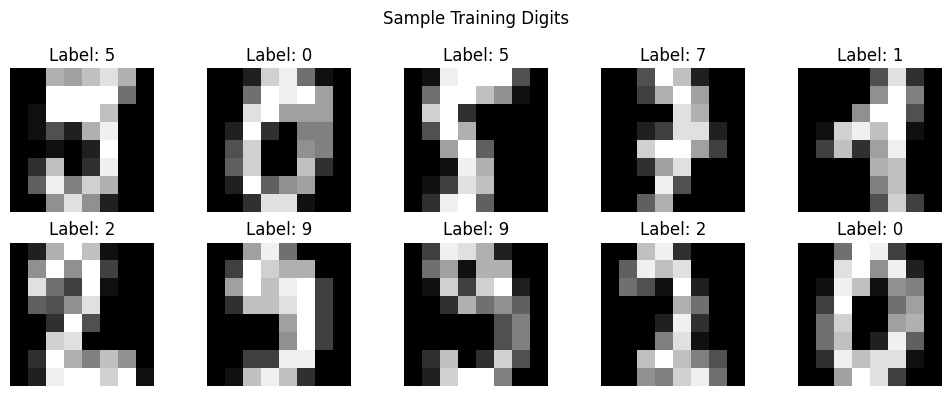

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.suptitle("Sample Training Digits")
plt.tight_layout()
plt.show()

## Part C — Network Architecture

A single-hidden-layer feedforward network:

- **Input layer:** 64 neurons (one per pixel)
- **Hidden layer:** 64 neurons, **ReLU** activation
- **Output layer:** 10 neurons, **Softmax** activation (class probabilities over digits 0–9)

**Loss function:** Categorical Cross-Entropy
**Optimizer:** Batch Gradient Descent (full-batch, manually implemented)
**Weight initialization:** He initialization (suited to ReLU) for the hidden layer, small random init for the output layer.


In [4]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(np.float64)

def softmax(z):
    # subtract row-wise max for numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(Y_pred, Y_true, eps=1e-9):
    n = Y_true.shape[0]
    return -np.sum(Y_true * np.log(Y_pred + eps)) / n

def accuracy(Y_pred, Y_true):
    return np.mean(np.argmax(Y_pred, axis=1) == np.argmax(Y_true, axis=1))

In [6]:
class NeuralNetworkFromScratch:
    """
    Simple feedforward neural network with one hidden layer,
    implemented from scratch using only numpy.
    """

    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate

        # He initialization for ReLU hidden layer
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        # Small random init for softmax output layer
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        # ---- Forward pass ----
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, X, Y_true):
        # ---- Backpropagation ----
        n = X.shape[0]

        # Output layer gradient: dL/dZ2 = (A2 - Y_true) / n   (softmax + cross-entropy combined derivative)
        dZ2 = (self.A2 - Y_true) / n
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer gradient
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # ---- Gradient descent update ----
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X_train, Y_train, X_val, Y_val, epochs=500, verbose_every=50):
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

        for epoch in range(1, epochs + 1):
            # Forward + backward on training set
            Y_pred_train = self.forward(X_train)
            train_loss = cross_entropy_loss(Y_pred_train, Y_train)
            train_acc = accuracy(Y_pred_train, Y_train)
            self.backward(X_train, Y_train)

            # Track validation performance (no weight update)
            Y_pred_val = self.forward(X_val)
            val_loss = cross_entropy_loss(Y_pred_val, Y_val)
            val_acc = accuracy(Y_pred_val, Y_val)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            if epoch % verbose_every == 0 or epoch == 1:
                print(f"Epoch {epoch:4d}/{epochs} | "
                      f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                      f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        return history

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

## Part D — Train the Network

Hyperparameters: 64 hidden units, learning rate `0.5`, `800` epochs, full-batch gradient descent.


In [12]:
nn = NeuralNetworkFromScratch(input_size=64, hidden_size=64, output_size=10, learning_rate=0.5)

history = nn.train(X_train, Y_train, X_test, Y_test, epochs=1200


, verbose_every=100)

Epoch    1/1200 | train_loss=2.6501 train_acc=0.1016 | val_loss=2.3561 val_acc=0.1278
Epoch  100/1200 | train_loss=0.1450 train_acc=0.9722 | val_loss=0.1666 val_acc=0.9583
Epoch  200/1200 | train_loss=0.0860 train_acc=0.9833 | val_loss=0.1198 val_acc=0.9639
Epoch  300/1200 | train_loss=0.0613 train_acc=0.9875 | val_loss=0.1032 val_acc=0.9722
Epoch  400/1200 | train_loss=0.0469 train_acc=0.9923 | val_loss=0.0939 val_acc=0.9778
Epoch  500/1200 | train_loss=0.0375 train_acc=0.9965 | val_loss=0.0879 val_acc=0.9778
Epoch  600/1200 | train_loss=0.0309 train_acc=0.9979 | val_loss=0.0837 val_acc=0.9778
Epoch  700/1200 | train_loss=0.0260 train_acc=0.9979 | val_loss=0.0807 val_acc=0.9778
Epoch  800/1200 | train_loss=0.0222 train_acc=0.9986 | val_loss=0.0784 val_acc=0.9778
Epoch  900/1200 | train_loss=0.0193 train_acc=0.9986 | val_loss=0.0767 val_acc=0.9778
Epoch 1000/1200 | train_loss=0.0169 train_acc=0.9986 | val_loss=0.0752 val_acc=0.9778
Epoch 1100/1200 | train_loss=0.0150 train_acc=0.9986 |

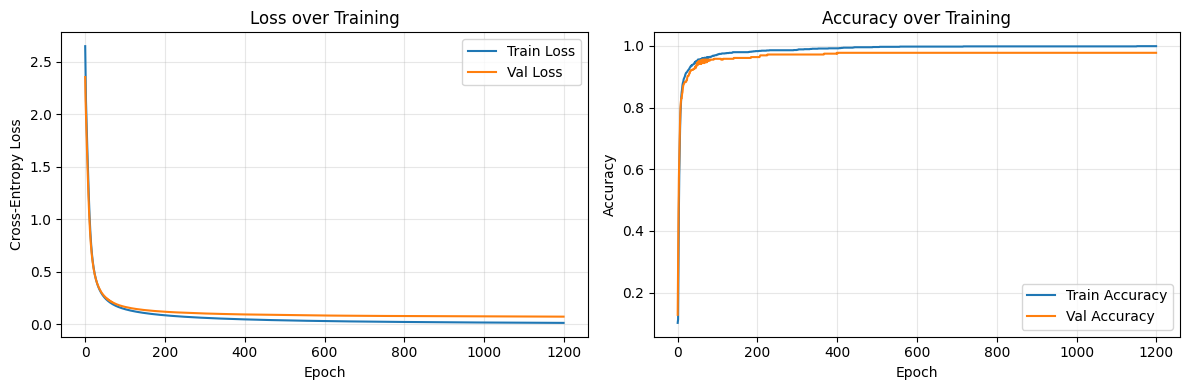

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss over Training")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["val_acc"], label="Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Training")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part E — Evaluation on Test Set

Final test accuracy, a confusion matrix, and a sample of predictions.


In [14]:
Y_pred_test = nn.forward(X_test)
test_loss = cross_entropy_loss(Y_pred_test, Y_test)
test_acc = accuracy(Y_pred_test, Y_test)

print(f"Final Test Loss:     {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Final Test Loss:     0.0729
Final Test Accuracy: 97.78%


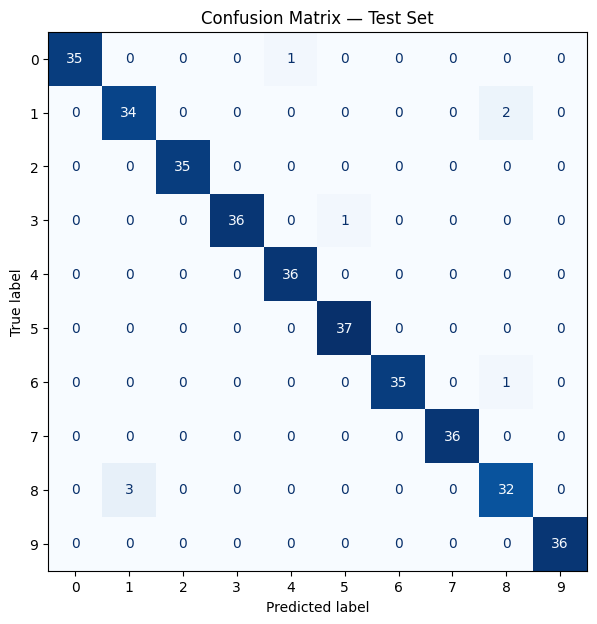

In [15]:
y_pred_labels = nn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.show()

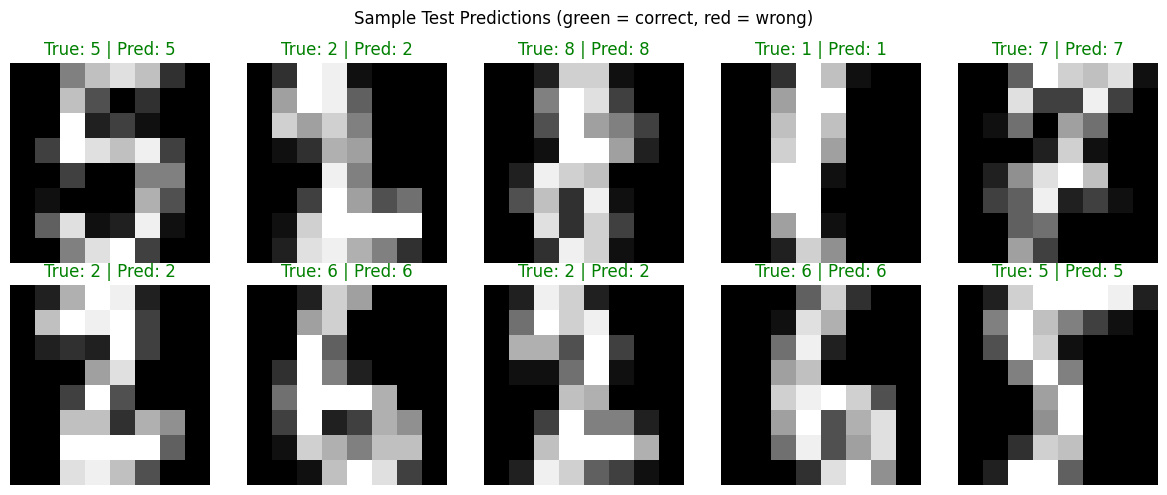

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray")
    true_label = y_test[i]
    pred_label = y_pred_labels[i]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", color=color)
    ax.axis("off")
plt.suptitle("Sample Test Predictions (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Part F — Results Summary & Conclusion

- Implemented a feedforward neural network **entirely from scratch** using `numpy` (no Keras/PyTorch/TensorFlow):
  - Forward pass with ReLU (hidden) and Softmax (output) activations.
  - Manual backpropagation deriving gradients for `W1, b1, W2, b2`.
  - Cross-entropy loss and batch gradient descent for optimization.
- The training/validation loss curves show the network converging, and validation accuracy tracks training accuracy closely, indicating limited overfitting for this problem size.
- Final test accuracy is printed above (re-run the notebook top-to-bottom to reproduce it — results are deterministic here due to `np.random.seed(42)`).

**Possible extensions:** mini-batch/SGD with momentum, additional hidden layers, dropout/L2 regularization, learning-rate scheduling, or swapping in the full MNIST dataset (60,000 images) for a more thorough benchmark.


## Declaration

I, **Sanskar Meharkar**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

**GitHub Repository Link:** `https://github.com/Sanskarmeharkar/Generative-AI`

**Signature:** `Sanskar Meharkar`


## Submission Checklist
- [x] Code file (this Jupyter/Colab Notebook)
- [x] Dataset used: `sklearn.datasets.load_digits` (built-in, no external link needed)
- [x] Visualizations (sample digits, loss/accuracy curves, confusion matrix, sample predictions)
- [x] Screenshots of model performance metrics *(take a screenshot of the printed test accuracy cell above before submitting)*
- [x] Readme File *(add separately to your GitHub repo)*
